In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [4]:
df = pd.read_csv("Wholesale customers data.csv")

In [5]:
X = df.select_dtypes(include=[np.number]).fillna(0)

In [6]:
X = StandardScaler().fit_transform(X)

In [7]:
wcss = []
for k in range(2, 11):
    wcss.append(KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X).inertia_)

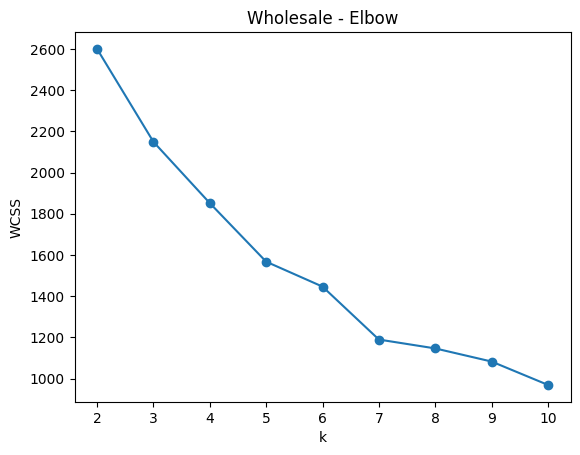

In [8]:
plt.plot(range(2, 11), wcss, marker="o")
plt.title("Wholesale - Elbow")
plt.xlabel("k"); plt.ylabel("WCSS")
plt.show()

In [9]:
k = 4
model = KMeans(n_clusters=k, random_state=42, n_init="auto")
df["Cluster"] = model.fit_predict(X)

In [10]:
print("Silhouette Score:", silhouette_score(X, df["Cluster"]))

Silhouette Score: 0.34819485747460033


In [11]:
df.to_csv("Wholesale_clustered.csv", index=False)

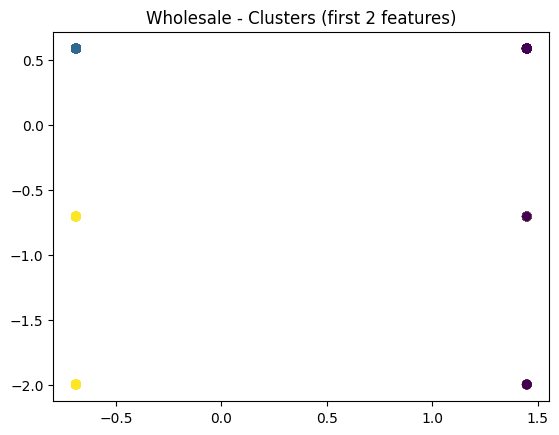

In [12]:
plt.scatter(X[:,0], X[:,1], c=df["Cluster"])
plt.title("Wholesale - Clusters (first 2 features)")
plt.show()